# Estimation de la valeur des biens immobiliers résidentiels au Sénégal
## 1. Chargement, nettoyage et analyse exploratoire des données

Mémoire M1 — Dakar Institute of Technology (DIT)

Ce notebook correspond à la section **5.1 Analyse exploratoire des données** du plan DIT. Il :
1. charge les annonces scrapées sur Expat-Dakar (`data/raw/expat_dakar_listings_raw.csv`),
2. nettoie les valeurs aberrantes / manquantes,
3. produit les visualisations exploratoires,
4. sauvegarde un dataset propre (`data/processed/expat_dakar_listings_clean.csv`) utilisé par le notebook de modélisation.

**Compatible Google Colab** : la cellule de chargement gère à la fois un chemin local et un upload manuel si le fichier n'est pas trouvé.


In [1]:
# Dépendances (déjà présentes sur Colab, installées ici par sécurité si absentes en local)
%pip install -q pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\snbam\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import os
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Chargement des données

Le fichier `expat_dakar_listings_raw.csv` a été produit par `src/scraper.py` (exécuté en local, hors Colab).
Si vous exécutez ce notebook dans Colab et que le fichier n'est pas déjà présent dans l'environnement de session, une invite d'upload s'affichera.


In [3]:
CANDIDATE_PATHS = [
    "data/raw/expat_dakar_listings_raw.csv",
    "../data/raw/expat_dakar_listings_raw.csv",
    "expat_dakar_listings_raw.csv",
]

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

raw_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if raw_path is None and IN_COLAB:
    from google.colab import files
    print("Fichier introuvable dans la session Colab. Uploadez expat_dakar_listings_raw.csv :")
    uploaded = files.upload()
    raw_path = next(iter(uploaded.keys()))

if raw_path is None:
    raise FileNotFoundError(
        "expat_dakar_listings_raw.csv introuvable. Placez-le dans data/raw/ "
        "(local) ou uploadez-le quand demandé (Colab)."
    )

df_raw = pd.read_csv(raw_path)
print(f"{len(df_raw)} lignes chargées depuis {raw_path}")
df_raw.head(10)


660 lignes chargées depuis ../data/raw/expat_dakar_listings_raw.csv


,listing_id,title,category,price_fcfa,currency,neighborhood,city_region,bedrooms,surface_m2,date_posted_raw,url
0,6706003,Villa R+2 à vendre aux Almadies Titre Foncier,Maisons à vendre,3.300000e+08,XOF,Almadies,Dakar,5.0,314.0,"Aujourd'hui, 17:24",https://www.expat-dakar.com/annonce/villa-r2-a...
1,6827403,Votre futur logement écologique à Bambilor,Maisons à vendre,4.000000e+07,XOF,Bambilor,Dakar,3.0,NaN,"Aujourd'hui, 12:25",https://www.expat-dakar.com/annonce/votre-futu...
2,6736189,Villa à vendre R+3 à Sicap Keur Massar,Maisons à vendre,1.600000e+08,XOF,Keur Massar,Dakar,NaN,NaN,"26. mai, 15:10",https://www.expat-dakar.com/annonce/villa-a-ve...
3,6827681,Maison à Vendre aux Parcelles Assainies Unité 11,Maisons à vendre,6.000000e+07,XOF,Parcelles Assainies,Dakar,7.0,200.0,"Aujourd'hui, 20:08",https://www.expat-dakar.com/annonce/maison-a-v...
4,6827149,Villa à vendre cité ALIOU SOW,Maisons à vendre,1.200000e+08,XOF,Golf,Dakar,3.0,150.0,"Hier, 22:04",https://www.expat-dakar.com/annonce/villa-a-ve...
5,6827050,Immeuble luxueux à vendre,Maisons à vendre,1.800000e+09,XOF,Almadies,Dakar,24.0,605.0,"Hier, 17:07",https://www.expat-dakar.com/annonce/immeuble-l...
6,6752266,Villa à vendre,Maisons à vendre,7.000000e+07,XOF,Mbao,Dakar,8.0,250.0,"Hier, 15:55",https://www.expat-dakar.com/annonce/villa-a-ve...
7,6826922,Villa basse de 370m2 à vendre a liberté 6,Maisons à vendre,2.600000e+08,XOF,Liberte 6,Dakar,4.0,370.0,"Hier, 13:25",https://www.expat-dakar.com/annonce/villa-bass...
8,6826532,IMMEUBLE R+1 A FINIR EN VENTE A LA CITE TACO R...,Maisons à vendre,9.000000e+07,XOF,Rufisque,Dakar,NaN,NaN,"Hier, 09:01",https://www.expat-dakar.com/annonce/immeuble-r...
9,6826521,R+8 Immeuble À vendre/VDN,Maisons à vendre,1.300000e+09,XOF,Liberte 6 extension,Dakar,32.0,250.0,"mercredi, 21:54",https://www.expat-dakar.com/annonce/r8-immeubl...


In [4]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   listing_id       660 non-null    int64  
 1   title            660 non-null    str    
 2   category         660 non-null    str    
 3   price_fcfa       660 non-null    float64
 4   currency         660 non-null    str    
 5   neighborhood     660 non-null    str    
 6   city_region      660 non-null    str    
 7   bedrooms         506 non-null    float64
 8   surface_m2       552 non-null    float64
 9   date_posted_raw  660 non-null    str    
 10  url              660 non-null    str    
dtypes: float64(3), int64(1), str(7)
memory usage: 167.9 KB


In [5]:
df_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
listing_id,660.0,NaN,NaN,NaN,6661050.898485,172168.021744,5428824.0,6611065.0,6711952.0,6771332.0,6827681.0
title,660,638,Maison à vendre,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,660,2,Maisons à vendre,330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_fcfa,660.0,NaN,NaN,NaN,262906677.018182,403065795.992661,0.0,80000000.0,160000000.0,291250000.0,5000000000.0
currency,660,1,XOF,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood,660,93,Almadies,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_region,660,5,Dakar,566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,506.0,NaN,NaN,NaN,4.086957,3.065675,1.0,3.0,3.0,5.0,32.0
surface_m2,552.0,NaN,NaN,NaN,359.068841,594.903505,21.0,150.0,210.0,321.0,8700.0
date_posted_raw,660,628,"lundi, 17:24",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Nettoyage des données

Étapes appliquées, dans l'ordre, avec le nombre de lignes affecté à chaque étape (traçabilité pour le rapport) :

1. Suppression des annonces sans prix exploitable (prix = 0, ou prix < 5 000 000 FCFA — seuil fixé après inspection manuelle des valeurs basses : en dessous, il s'agit systématiquement d'incohérences flagrantes — ex. une villa de 1000 m² à Ngor, quartier où le prix moyen dépasse 200M FCFA, affichée à 1,5M FCFA — plutôt que de véritables biens bon marché).
2. Suppression des biens hors périmètre "résidentiel unitaire" (surface ou nombre de chambres extrêmes, typiques d'immeubles entiers plutôt que d'un logement/maison individuelle).
3. Traitement des valeurs manquantes de `bedrooms` et `surface_m2` par imputation par la médiane du groupe (catégorie × ville/région).
4. Nettoyage du texte (accents mal encodés dus au scraping) et normalisation des catégories.


In [6]:
df = df_raw.copy()

# Ré-encodage : le HTML source contient des accents mal décodés par endroits (encodage windows-1252 vs utf-8)
def fix_mojibake(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return s

text_cols = ["title", "category", "neighborhood", "city_region"]
for c in text_cols:
    df[c] = df[c].apply(fix_mojibake)

df["category"] = df["category"].replace({
    "Maisons vendre": "Maisons à vendre",
    "Appartements vendre": "Appartements à vendre",
})

df[text_cols].head()


,title,category,neighborhood,city_region
0,Villa R+2 à vendre aux Almadies Titre Foncier,Maisons à vendre,Almadies,Dakar
1,Votre futur logement écologique à Bambilor,Maisons à vendre,Bambilor,Dakar
2,Villa à vendre R+3 à Sicap Keur Massar,Maisons à vendre,Keur Massar,Dakar
3,Maison à Vendre aux Parcelles Assainies Unité 11,Maisons à vendre,Parcelles Assainies,Dakar
4,Villa à vendre cité ALIOU SOW,Maisons à vendre,Golf,Dakar


In [7]:
n0 = len(df)

# 1. Prix non exploitables (annonce sans prix réel affiché, ou erreur manifeste de saisie)
# Seuil fixé à 5M FCFA après inspection manuelle : les annonces en dessous (ex. villa 1000 m² à Ngor
# affichée à 1,5M FCFA, alors que le prix moyen du quartier dépasse 200M FCFA) sont des incohérences
# flagrantes (prix sur demande, mensualité, ou erreur de saisie), tandis que des maisons à 10-20M FCFA
# dans des villes secondaires (Kaolack, Mbour, Mboro) restent plausibles et sont conservées.
MIN_PLAUSIBLE_PRICE = 5_000_000  # FCFA
df = df[df["price_fcfa"] > MIN_PLAUSIBLE_PRICE].copy()
n1 = len(df)
print(f"Étape 1 (prix non exploitable) : {n0 - n1} lignes supprimées, {n1} restantes")


Étape 1 (prix non exploitable) : 43 lignes supprimées, 617 restantes


In [8]:
# 2. Hors périmètre résidentiel unitaire : surface ou nb de chambres extrêmes (probable immeuble entier)
MAX_SURFACE = 2000   # m²
MAX_BEDROOMS = 15

mask_outlier = (df["surface_m2"] > MAX_SURFACE) | (df["bedrooms"] > MAX_BEDROOMS)
n_before = len(df)
df = df[~mask_outlier.fillna(False)].copy()
n2 = len(df)
print(f"Étape 2 (hors périmètre résidentiel unitaire) : {n_before - n2} lignes supprimées, {n2} restantes")


Étape 2 (hors périmètre résidentiel unitaire) : 14 lignes supprimées, 603 restantes


In [9]:
# 3. Imputation des valeurs manquantes par la médiane du groupe (catégorie x ville/région), avec repli sur la médiane globale
for col in ["surface_m2", "bedrooms"]:
    group_median = df.groupby(["category", "city_region"])[col].transform("median")
    df[col] = df[col].fillna(group_median)
    df[col] = df[col].fillna(df[col].median())

print("Valeurs manquantes restantes :")
print(df[["surface_m2", "bedrooms"]].isna().sum())


Valeurs manquantes restantes :
surface_m2    0
bedrooms      0
dtype: int64


In [10]:
print(f"Dataset nettoyé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.describe().T


Dataset nettoyé : 603 lignes, 11 colonnes


,count,mean,std,min,25%,50%,75%,max
listing_id,603.0,6.659563e+06,1.763243e+05,5428824.0,6604440.5,6712705.0,6773968.0,6.827681e+06
price_fcfa,603.0,2.530473e+08,3.208300e+08,10000000.0,91000000.0,165000000.0,292500000.0,3.200000e+09
bedrooms,603.0,3.864013e+00,1.696610e+00,1.0,3.0,3.0,5.0,1.500000e+01
surface_m2,603.0,2.849685e+02,2.468766e+02,21.0,157.0,200.0,300.0,2.000000e+03


## Analyse exploratoire (EDA)


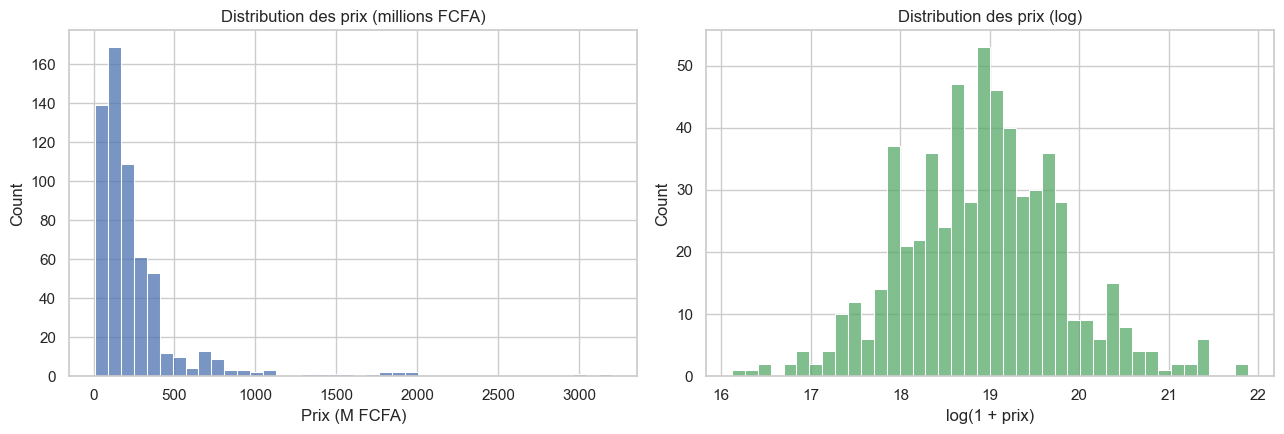

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["price_fcfa"] / 1e6, bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution des prix (millions FCFA)")
axes[0].set_xlabel("Prix (M FCFA)")

sns.histplot(np.log1p(df["price_fcfa"]), bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution des prix (log)")
axes[1].set_xlabel("log(1 + prix)")

plt.tight_layout()
plt.show()


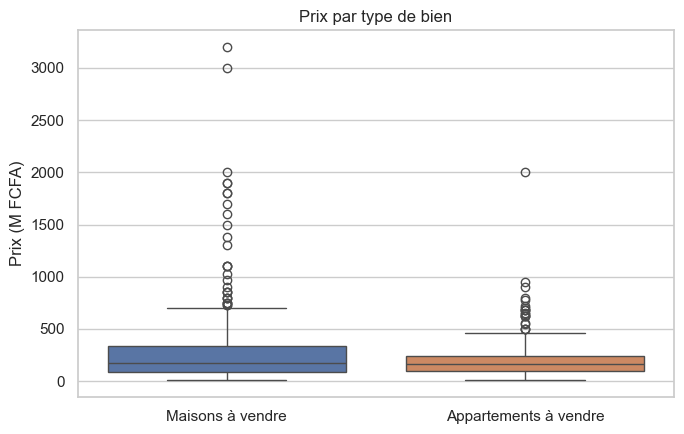

In [12]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="category", y=df["price_fcfa"] / 1e6, hue="category", legend=False)
plt.ylabel("Prix (M FCFA)")
plt.xlabel("")
plt.title("Prix par type de bien")
plt.tight_layout()
plt.show()


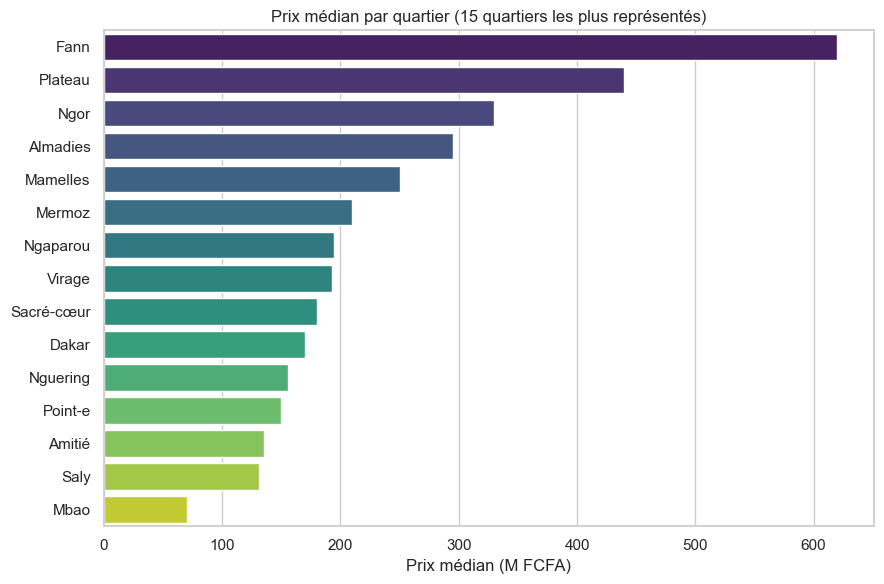

In [13]:
top_neighborhoods = df["neighborhood"].value_counts().head(15).index
subset = df[df["neighborhood"].isin(top_neighborhoods)]

median_by_neighborhood = (
    subset.groupby("neighborhood")["price_fcfa"].median().sort_values(ascending=False) / 1e6
)

plt.figure(figsize=(9, 6))
sns.barplot(x=median_by_neighborhood.values, y=median_by_neighborhood.index, hue=median_by_neighborhood.index, palette="viridis", legend=False)
plt.xlabel("Prix médian (M FCFA)")
plt.ylabel("")
plt.title("Prix médian par quartier (15 quartiers les plus représentés)")
plt.tight_layout()
plt.show()


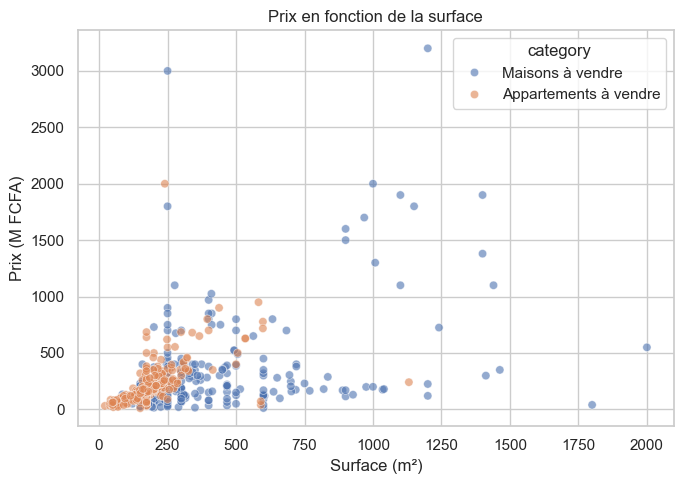

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="surface_m2", y=df["price_fcfa"] / 1e6, hue="category", alpha=0.6)
plt.xlabel("Surface (m²)")
plt.ylabel("Prix (M FCFA)")
plt.title("Prix en fonction de la surface")
plt.tight_layout()
plt.show()


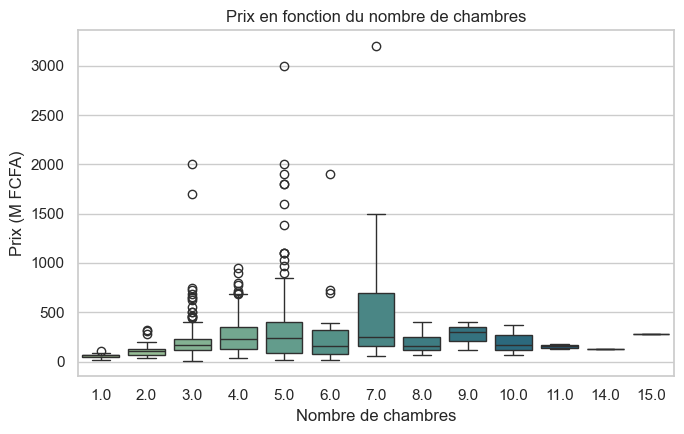

In [15]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="bedrooms", y=df["price_fcfa"] / 1e6, hue="bedrooms", legend=False, palette="crest")
plt.xlabel("Nombre de chambres")
plt.ylabel("Prix (M FCFA)")
plt.title("Prix en fonction du nombre de chambres")
plt.tight_layout()
plt.show()


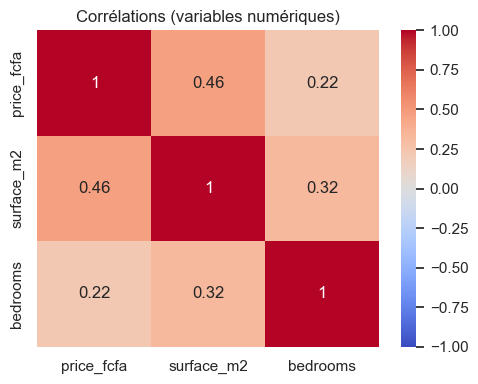

In [16]:
numeric_cols = ["price_fcfa", "surface_m2", "bedrooms"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélations (variables numériques)")
plt.tight_layout()
plt.show()


In [17]:
print("Répartition géographique (ville/région) :")
print(df["city_region"].value_counts())


Répartition géographique (ville/région) :
city_region
Dakar          515
Thiès           84
Kaolack          2
Saint-Louis      1
Autres           1
Name: count, dtype: int64


### Constats principaux (à reprendre dans le rapport, section 5.1)

- Distribution des prix fortement asymétrique à droite (quelques biens haut de gamme) — justifie une transformation log pour les modèles linéaires.
- La surface est, sans surprise, la variable la plus corrélée au prix.
- Le marché est très concentré géographiquement (Dakar très majoritaire) — limite explicite à mentionner sur la capacité de généralisation nationale du modèle.
- Le nombre de chambres a un effet positif mais moins net que la surface, avec davantage de variance (des maisons à nombre de chambres identique peuvent avoir des surfaces très différentes).


## Sauvegarde du dataset nettoyé


In [18]:
OUTPUT_CANDIDATES = ["data/processed", "../data/processed", "."]
output_dir = next((p for p in OUTPUT_CANDIDATES if os.path.isdir(os.path.dirname(p) or ".") or os.path.isdir(p)), ".")
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "expat_dakar_listings_clean.csv")
df.to_csv(output_path, index=False)
print(f"Dataset nettoyé sauvegardé : {output_path} ({df.shape[0]} lignes, {df.shape[1]} colonnes)")


Dataset nettoyé sauvegardé : ../data/processed\expat_dakar_listings_clean.csv (603 lignes, 11 colonnes)
